<a href="https://colab.research.google.com/github/AnjanaGunarathna/DL_News_Detection/blob/Anjana(LSTM)/News_Detection_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from keras.models import Model
from keras.layers import Embedding, LSTM, Dense, Input, GlobalMaxPooling1D, Dropout
from tensorflow.keras.optimizers import Adam

In [74]:
!pip install kaggle --quiet

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset
!unzip -o fake-and-real-news-dataset.zip -d /content/data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
  0% 0.00/41.0M [00:00<?, ?B/s]
100% 41.0M/41.0M [00:00<00:00, 1.55GB/s]
Archive:  fake-and-real-news-dataset.zip
  inflating: /content/data/Fake.csv  
  inflating: /content/data/True.csv  


In [76]:
Fake = pd.read_csv("/content/data/Fake.csv")
TrueNews = pd.read_csv("/content/data/True.csv")

Fake['label'] = 0
TrueNews['label'] = 1

Fake.drop(columns=["title", "subject", "date"], inplace=True)
TrueNews.drop(columns=["title", "subject", "date"], inplace=True)

News = pd.concat([Fake, TrueNews], ignore_index=True)
News.drop_duplicates(inplace=True)
print("Dataset size:", News.shape)
print(News['label'].value_counts())

Dataset size: (38647, 2)
label
1    21192
0    17455
Name: count, dtype: int64


In [77]:
Fake

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0
...,...,...
23476,21st Century Wire says As 21WIRE reported earl...,0
23477,21st Century Wire says It s a familiar theme. ...,0
23478,Patrick Henningsen 21st Century WireRemember ...,0
23479,21st Century Wire says Al Jazeera America will...,0


In [78]:
TrueNews

,text,label
0,WASHINGTON (Reuters) - The head of a conservat...,1
1,WASHINGTON (Reuters) - Transgender people will...,1
2,WASHINGTON (Reuters) - The special counsel inv...,1
3,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,1
...,...,...
21412,BRUSSELS (Reuters) - NATO allies on Tuesday we...,1
21413,"LONDON (Reuters) - LexisNexis, a provider of l...",1
21414,MINSK (Reuters) - In the shadow of disused Sov...,1
21415,MOSCOW (Reuters) - Vatican Secretary of State ...,1


Preprocessing

In [79]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def process_text(text):
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 3]
    return ' '.join(words)


News['clean_text'] = News['text'].apply(process_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Dataset split

In [80]:
X = News['clean_text']
y = News['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 150
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(News['clean_text'])

vocab_size = len(tokenizer.word_index) + 1
print("Vocab size:", vocab_size)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post')

Vocab size: 200050


In [82]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

y_train_one_hot = tf.keras.utils.to_categorical(y_train_enc)
y_test_one_hot = tf.keras.utils.to_categorical(y_test_enc)

Model build

In [83]:
input_layer = Input(shape=(maxlen,))
embedding = Embedding(vocab_size, 100)(input_layer)
drop1 = Dropout(0.5)(embedding)
lstm = LSTM(150, return_sequences=True)(drop1)
drop2 = Dropout(0.5)(lstm)
pool = GlobalMaxPooling1D()(drop2)
dense1 = Dense(64, activation='relu')(pool)
drop3 = Dropout(0.5)(dense1)
output = Dense(2, activation='softmax')(drop3)

model = Model(inputs=input_layer, outputs=output)

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 150, 100)       │    20,005,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 150, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 150, 150)       │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 150, 150)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 150)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         9,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,165,394 (76.92 MB)

 Trainable params: 20,165,394 (76.92 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
history = model.fit(
    X_train_pad, y_train_one_hot,
    epochs=10,
    validation_data=(X_test_pad, y_test_one_hot),
    batch_size=128,
    verbose=1
)


Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.6135 - loss: 0.6167 - val_accuracy: 0.9420 - val_loss: 0.2127
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9515 - loss: 0.1344 - val_accuracy: 0.9622 - val_loss: 0.1673
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9745 - loss: 0.0725 - val_accuracy: 0.9652 - val_loss: 0.1245
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9831 - loss: 0.0520 - val_accuracy: 0.9639 - val_loss: 0.0979
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9887 - loss: 0.0320 - val_accuracy: 0.9657 - val_loss: 0.0918
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9938 - loss: 0.0206 - val_accuracy: 0.9646 - val_loss: 0.0916
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9938 - loss: 0.0245 - val_accuracy: 0.9639 - val_loss: 0.0990
Epoch 8/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9964 - loss: 0.0134 - val_acc

In [85]:
loss, accuracy = model.evaluate(X_test_pad, y_test_one_hot)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9672 - loss: 0.0817
Test Loss: 0.09139172732830048
Test Accuracy: 0.9662354588508606


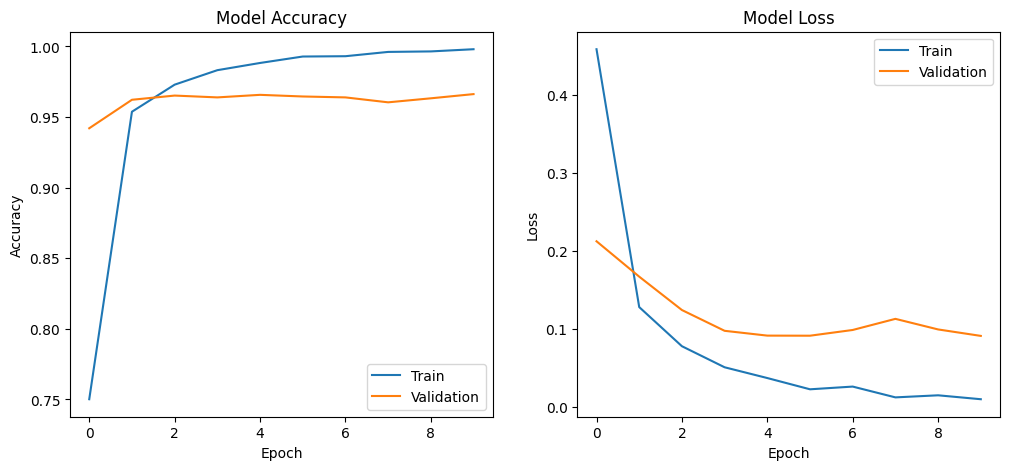

In [86]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


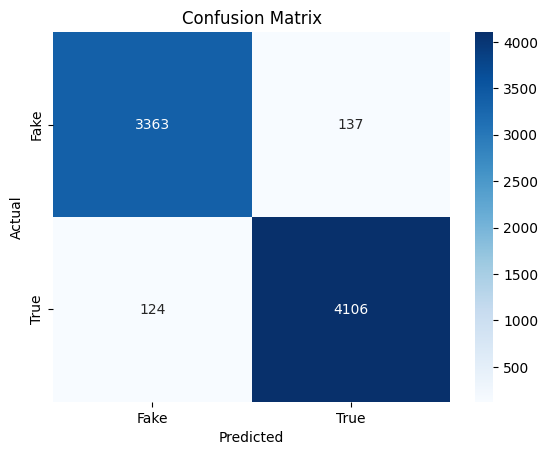


Classification Report:
               precision    recall  f1-score   support

        Fake       0.96      0.96      0.96      3500
        True       0.97      0.97      0.97      4230

    accuracy                           0.97      7730
   macro avg       0.97      0.97      0.97      7730
weighted avg       0.97      0.97      0.97      7730



In [87]:
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n", classification_report(y_true, y_pred_classes, target_names=['Fake', 'True']))

In [97]:
print("Sample Test Predictions:\n")

num_samples = 10
sample_indices = np.random.choice(len(X_test), num_samples, replace=False)

for i in sample_indices:
    text = X_test.iloc[i]
    actual = "TRUE" if y_test.iloc[i] == 1 else "FAKE"


    clean = process_text(text)
    seq = tokenizer.texts_to_sequences([clean])
    pad = pad_sequences(seq, maxlen=maxlen, padding='post')
    pred = model.predict(pad)
    label = np.argmax(pred, axis=1)[0]
    confidence = float(np.max(pred))

    predicted = "TRUE" if label == 1 else "FAKE"

    print(f"News: {text[:300]}...")
    print(f"Actual: {actual}")
    print(f"Predicted: {predicted}  (Confidence: {confidence*100:.2f}%)")
    print("-"*100)

Sample Test Predictions:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
News: reuters saudi arabia detained cleric intellectual activist said social medium tuesday widening apparent crackdown potential opponent conservative kingdom absolute ruler crackdown come amid widespread speculation denied official king salman intends abdicate favor crown prince mohammed salman already ...
Actual: TRUE
Predicted: TRUE  (Confidence: 99.71%)
----------------------------------------------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
News: brusselswashington reuters president donald trump return overseas trip white house plan launch aggressive effort push back allegation involving russia presidential campaign tackling headon scandal threatened consume young presidency trump adviser planning establish room combat mounting question comm...
Actual: TRUE
Predicted: TRUE  (Confidence: 99.64%)
---------------------------------------------------------------------------

In [105]:
def predict_news(text):
    clean = process_text(text)
    seq = tokenizer.texts_to_sequences([clean])
    pad = pad_sequences(seq, maxlen=maxlen, padding='post')
    pred = model.predict(pad)
    label = np.argmax(pred, axis=1)[0]
    confidence = float(np.max(pred))
    print(f"\nConfidence: {confidence*100:.2f}%")
    if label == 1:
        print("This news is REAL")
    else:
        print("This news is FAKE")

In [106]:
predict_news("ivanka trump eponymous woman fashion line reporting record sale figure despite call boycott controversy surrounding president trump since beginning february best performing week history brand abigail klem president ivanka trump fashion brand tell refinery interview published tuesday several differen...")
predict_news("Four U.S. Army special operations soldiers were presumed killed when their Black Hawk helicopter crashed this week during a routine training exercise in a remote area of Washington state near Joint Base Lewis-McChord, the Army said on Friday.")
predict_news("Trump campaign adviser George Papadopoulos told an Australian diplomat in May 2016 that Russia had political dirt on Democratic presidential candidate Hillary Clinton, the New York Times reported on Saturday.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Confidence: 99.73%
This news is FAKE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Confidence: 97.30%
This news is REAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Confidence: 97.80%
This news is REAL
